# CSE438 Lab 03: Point Operations and Gray-Level Transformations

**Course:** CSE438 Digital Image Processing  
**Lab topic:** Point operations, contrast stretching, intensity transformation, log transformation, and gamma correction  
**Dataset:** Betel Leaf Image Dataset from Bangladesh  
**Platform:** Kaggle Notebook

This lab uses real Betel Leaf disease images to demonstrate how pixel-wise transformations modify image intensity, contrast, and visual interpretability. The operations in this lab are foundational for later enhancement, filtering, segmentation, and feature extraction tasks.

## Learning Objectives

After completing this lab, students should be able to:

1. implement basic point operations on grayscale images;
2. apply contrast stretching using min-max normalization;
3. use logarithmic transformation for spectrum visualization;
4. apply power-law or gamma correction using different gamma values;
5. visualize and interpret intensity transformation curves.

## Lab Tasks

1. Negate a grayscale image.  
2. Apply contrast stretching using min-max normalization.  
3. Implement log transformation for spectrum display.  
4. Apply gamma correction with different gamma values.  
5. Visualize transformation curves.

## 1. Import Required Libraries

The notebook uses `OpenCV` for image loading and transformation, `NumPy` for numerical computation, and `Matplotlib` for visualization. These libraries are available in Kaggle by default.

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = False

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 4.13.0
NumPy version: 2.0.2


## 2. Dataset Configuration

Kaggle may mount the same dataset under slightly different directory names. The following cell checks multiple possible root paths and selects the first valid one.

Expected class folders:

- `Bacterial Leaf Disease`
- `Dried Leaf`
- `Fungal Brown Spot Disease`
- `Healthy Leaf`

In [2]:
# Possible Kaggle dataset roots.
# The first path follows the path given in the lab instruction.
# The second path follows the usual Kaggle dataset mounting convention.

CANDIDATE_ROOTS = [
    Path("/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh/data"),
]

DATASET_ROOT = None
for root in CANDIDATE_ROOTS:
    if root.exists():
        DATASET_ROOT = root
        break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Dataset root was not found. Please add the Kaggle dataset to this notebook. "
        "Dataset: rifat963/betel-leaf-image-dataset-from-bangladesh"
    )

TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

EXPECTED_CLASSES = [
    "Bacterial Leaf Disease",
    "Dried Leaf",
    "Fungal Brown Spot Disease",
    "Healthy Leaf",
]

print("Dataset root:", DATASET_ROOT)
print("Train directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

Dataset root: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh
Train directory exists: True
Test directory exists: True


In [3]:
def list_image_files(folder):
    """Return image files from a folder using common image extensions."""
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    folder = Path(folder)
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in extensions])


records = []
for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for class_name in EXPECTED_CLASSES:
        class_dir = split_dir / class_name
        image_count = len(list_image_files(class_dir)) if class_dir.exists() else 0
        records.append({
            "split": split_name,
            "class_name": class_name,
            "image_count": image_count,
            "folder_exists": class_dir.exists(),
        })

count_df = pd.DataFrame(records)
count_df

,split,class_name,image_count,folder_exists
0,train,Bacterial Leaf Disease,609,True
1,train,Dried Leaf,597,True
2,train,Fungal Brown Spot Disease,588,True
3,train,Healthy Leaf,594,True
4,test,Bacterial Leaf Disease,47,True
5,test,Dried Leaf,51,True
6,test,Fungal Brown Spot Disease,54,True
7,test,Healthy Leaf,49,True


## 3. Utility Functions

These helper functions keep the later task cells concise and readable. OpenCV reads color images in **BGR** order, so color images are converted to **RGB** before displaying them with Matplotlib.

In [4]:
def read_image_rgb(path):
    """Read a color image using OpenCV and convert BGR to RGB."""
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb


def read_image_gray(path):
    """Read an image directly as an 8-bit grayscale image."""
    image_gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image_gray is None:
        raise ValueError(f"Could not read image: {path}")
    return image_gray


def show_image_grid(images, titles=None, cmap=None, cols=3, figsize=(14, 8)):
    """Display images in a compact grid."""
    n = len(images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)

    for i, image in enumerate(images, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(image, cmap=cmap)
        if titles is not None:
            plt.title(titles[i - 1], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def save_gray_image(path, image):
    """Save a grayscale image after clipping values to [0, 255]."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    image_uint8 = np.clip(image, 0, 255).astype(np.uint8)
    cv2.imwrite(str(path), image_uint8)
    return path


OUTPUT_DIR = Path("/kaggle/working/cse438_lab03_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/cse438_lab03_outputs


## 4. Select a Working Image

For this lab, one image is selected from the training set. The same functions can be applied to any image from any class.

Selected class: Healthy Leaf
Selected image: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Healthy Leaf/Healthy_Leaf-1-_jpg.rf.2bbab1284996789ca5375cbca7337959.jpg
RGB shape: (800, 600, 3)
Grayscale shape: (800, 600)
Data type: uint8
Gray intensity range: 0 to 241


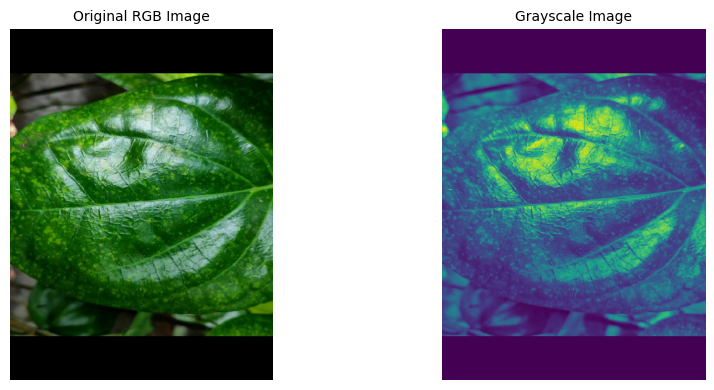

In [5]:
# Collect training images class-wise.
train_images_by_class = {
    class_name: list_image_files(TRAIN_DIR / class_name)
    for class_name in EXPECTED_CLASSES
}

# Select the first available image from Healthy Leaf if possible; otherwise select the first image from any class.
preferred_class = "Healthy Leaf"

if len(train_images_by_class.get(preferred_class, [])) > 0:
    selected_path = train_images_by_class[preferred_class][0]
    selected_class = preferred_class
else:
    selected_path = None
    selected_class = None
    for class_name, files in train_images_by_class.items():
        if len(files) > 0:
            selected_path = files[0]
            selected_class = class_name
            break

if selected_path is None:
    raise FileNotFoundError("No training image was found in the expected class folders.")

image_rgb = read_image_rgb(selected_path)
image_gray = read_image_gray(selected_path)

print("Selected class:", selected_class)
print("Selected image:", selected_path)
print("RGB shape:", image_rgb.shape)
print("Grayscale shape:", image_gray.shape)
print("Data type:", image_gray.dtype)
print("Gray intensity range:", int(image_gray.min()), "to", int(image_gray.max()))

show_image_grid(
    [image_rgb, image_gray],
    titles=["Original RGB Image", "Grayscale Image"],
    cmap=None,
    cols=2,
    figsize=(10, 4)
)

## 5. Display Sample Images from All Classes

This step verifies that the dataset is correctly mounted and gives a quick visual idea of the four classes before applying intensity transformations.

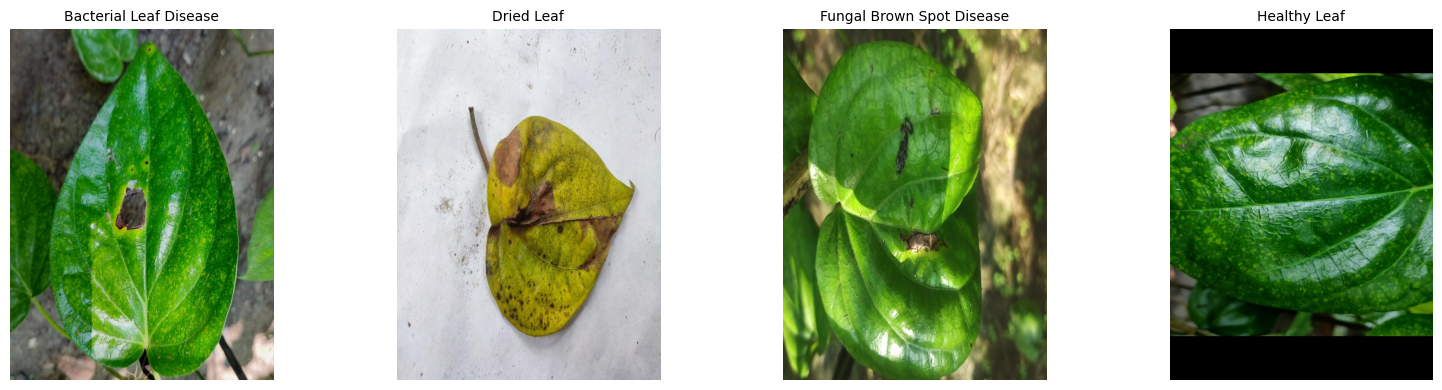

In [6]:
sample_images = []
sample_titles = []

for class_name in EXPECTED_CLASSES:
    files = train_images_by_class.get(class_name, [])
    if len(files) > 0:
        sample_images.append(read_image_rgb(files[0]))
        sample_titles.append(class_name)

show_image_grid(
    sample_images,
    titles=sample_titles,
    cols=4,
    figsize=(16, 4)
)

## Task 1: Negate a Grayscale Image

Image negation reverses intensity values. For an 8-bit grayscale image, the transformation is:

\[
s = 255 - r
\]

where `r` is the input pixel value and `s` is the transformed output pixel value.

Dark regions become bright, and bright regions become dark. This operation is useful for emphasizing details that are visually less clear in the original intensity arrangement.

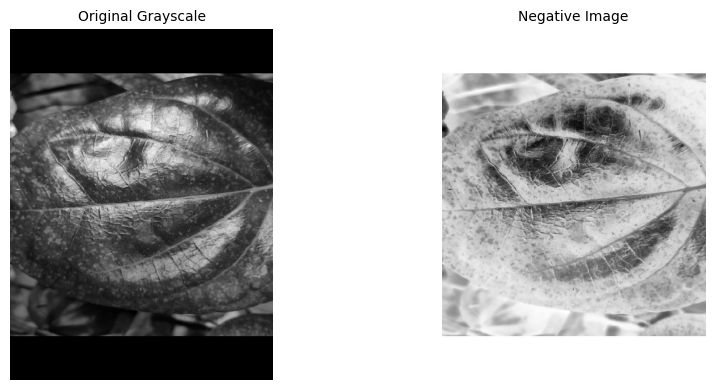

Original pixel range: 0 to 241
Negative pixel range: 14 to 255


In [7]:
negative_gray = 255 - image_gray

save_gray_image(OUTPUT_DIR / "task01_negative_gray.png", negative_gray)

show_image_grid(
    [image_gray, negative_gray],
    titles=["Original Grayscale", "Negative Image"],
    cmap="gray",
    cols=2,
    figsize=(10, 4)
)

print("Original pixel range:", int(image_gray.min()), "to", int(image_gray.max()))
print("Negative pixel range:", int(negative_gray.min()), "to", int(negative_gray.max()))

### Histogram Comparison for Image Negation

The negative image has the same number of pixels as the original image, but the intensity distribution is mirrored around the middle of the range.

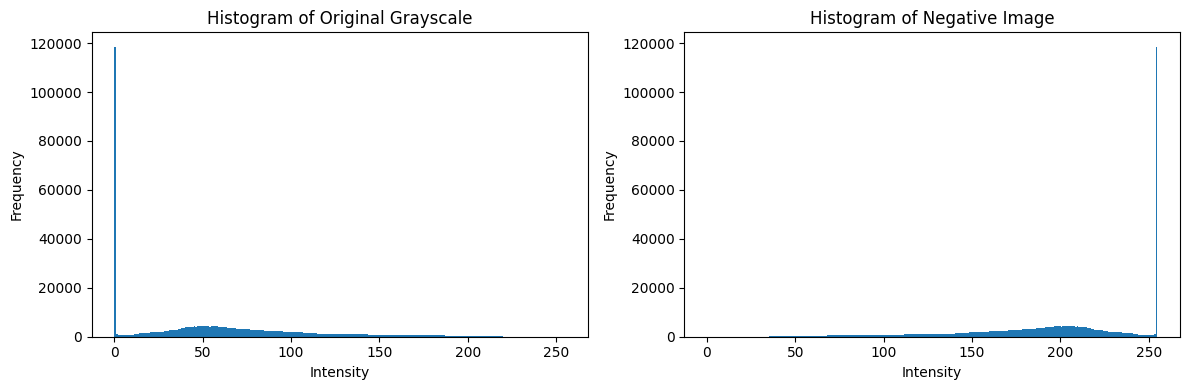

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(image_gray.ravel(), bins=256, range=(0, 255))
plt.title("Histogram of Original Grayscale")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(negative_gray.ravel(), bins=256, range=(0, 255))
plt.title("Histogram of Negative Image")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Task 2: Contrast Stretching using Min-Max Normalization

Contrast stretching expands a narrow intensity range into a wider range. The standard min-max normalization is:

\[
s = \frac{r-r_{min}}{r_{max}-r_{min}} \times 255
\]

This task first creates a low-contrast version of the image and then stretches it back to the full 8-bit range.

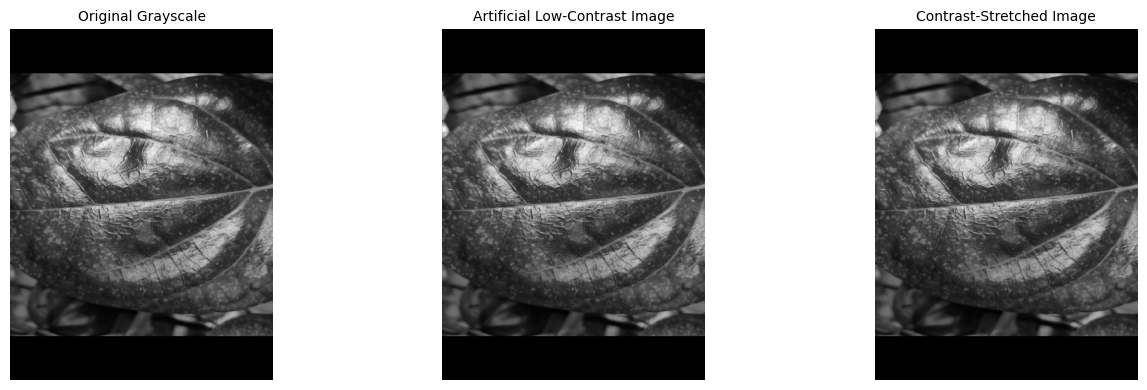

Low-contrast range: 70 to 170
Stretched range: 0 to 255


In [9]:
def contrast_stretch_minmax(gray_image):
    """Apply min-max contrast stretching to an 8-bit grayscale image."""
    gray_float = gray_image.astype(np.float32)
    min_val = gray_float.min()
    max_val = gray_float.max()

    if max_val == min_val:
        return np.zeros_like(gray_image, dtype=np.uint8)

    stretched = (gray_float - min_val) / (max_val - min_val) * 255.0
    return np.clip(stretched, 0, 255).astype(np.uint8)


# A low-contrast image is generated to make the effect easier to observe.
low_contrast_gray = cv2.normalize(
    image_gray,
    None,
    alpha=70,
    beta=170,
    norm_type=cv2.NORM_MINMAX
).astype(np.uint8)

stretched_gray = contrast_stretch_minmax(low_contrast_gray)

save_gray_image(OUTPUT_DIR / "task02_low_contrast_gray.png", low_contrast_gray)
save_gray_image(OUTPUT_DIR / "task02_contrast_stretched_gray.png", stretched_gray)

show_image_grid(
    [image_gray, low_contrast_gray, stretched_gray],
    titles=["Original Grayscale", "Artificial Low-Contrast Image", "Contrast-Stretched Image"],
    cmap="gray",
    cols=3,
    figsize=(14, 4)
)

print("Low-contrast range:", int(low_contrast_gray.min()), "to", int(low_contrast_gray.max()))
print("Stretched range:", int(stretched_gray.min()), "to", int(stretched_gray.max()))

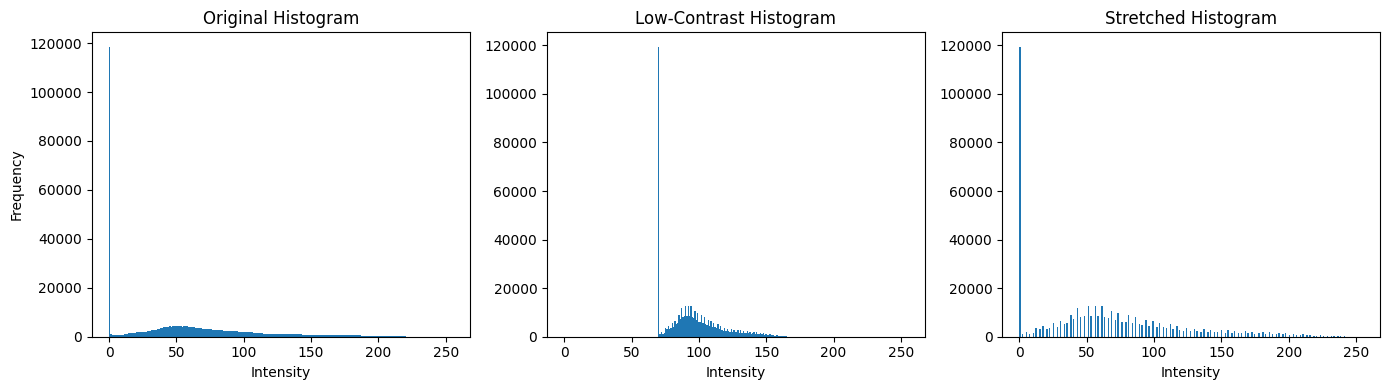

In [10]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(image_gray.ravel(), bins=256, range=(0, 255))
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(low_contrast_gray.ravel(), bins=256, range=(0, 255))
plt.title("Low-Contrast Histogram")
plt.xlabel("Intensity")

plt.subplot(1, 3, 3)
plt.hist(stretched_gray.ravel(), bins=256, range=(0, 255))
plt.title("Stretched Histogram")
plt.xlabel("Intensity")

plt.tight_layout()
plt.show()

## Task 3: Log Transformation for Spectrum Display

Log transformation compresses large intensity variations and expands smaller values. It is frequently used when displaying Fourier magnitude spectra, because the DC component and low-frequency values may dominate the display.

The transformation is:

\[
s = c \log(1+r)
\]

where `c` is a scaling constant and `r` is the input magnitude value.

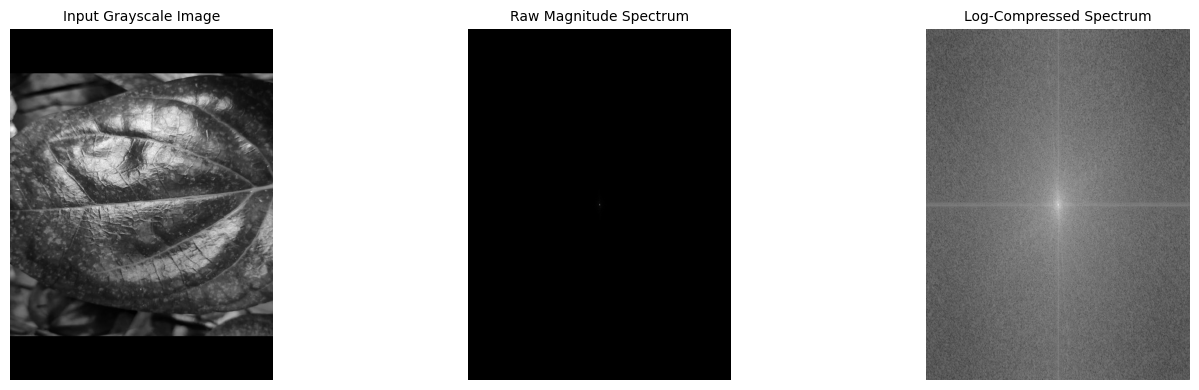

Raw magnitude range: 4.075875893561631 to 28309437.0
Log magnitude range: 1.6244990999002946 to 17.158705805248506


In [11]:
def normalize_to_uint8(array):
    """Normalize a numerical array to the 8-bit range [0, 255]."""
    array = array.astype(np.float32)
    min_val = array.min()
    max_val = array.max()

    if max_val == min_val:
        return np.zeros_like(array, dtype=np.uint8)

    normalized = (array - min_val) / (max_val - min_val) * 255.0
    return np.clip(normalized, 0, 255).astype(np.uint8)


# Compute the 2D Fourier transform.
f_transform = np.fft.fft2(image_gray)
f_shift = np.fft.fftshift(f_transform)

# Magnitude spectrum before log compression.
magnitude = np.abs(f_shift)

# Log-compressed spectrum.
log_magnitude = np.log1p(magnitude)

magnitude_display = normalize_to_uint8(magnitude)
log_magnitude_display = normalize_to_uint8(log_magnitude)

save_gray_image(OUTPUT_DIR / "task03_raw_magnitude_spectrum.png", magnitude_display)
save_gray_image(OUTPUT_DIR / "task03_log_magnitude_spectrum.png", log_magnitude_display)

show_image_grid(
    [image_gray, magnitude_display, log_magnitude_display],
    titles=["Input Grayscale Image", "Raw Magnitude Spectrum", "Log-Compressed Spectrum"],
    cmap="gray",
    cols=3,
    figsize=(15, 4)
)

print("Raw magnitude range:", float(magnitude.min()), "to", float(magnitude.max()))
print("Log magnitude range:", float(log_magnitude.min()), "to", float(log_magnitude.max()))

### Direct Log Transformation on a Grayscale Image

The same log formula can also be applied directly to a grayscale image. It usually brightens darker regions while compressing very bright regions.

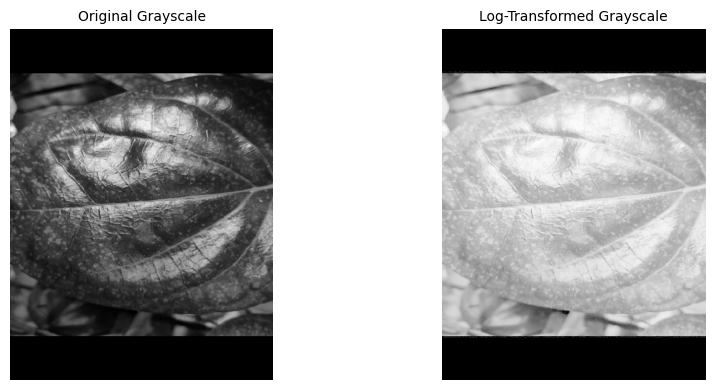

In [12]:
def log_transform_uint8(gray_image):
    """Apply log transformation to an 8-bit grayscale image."""
    gray_float = gray_image.astype(np.float32)
    c = 255.0 / np.log1p(gray_float.max())
    transformed = c * np.log1p(gray_float)
    return np.clip(transformed, 0, 255).astype(np.uint8)


log_gray = log_transform_uint8(image_gray)

save_gray_image(OUTPUT_DIR / "task03_log_transformed_gray.png", log_gray)

show_image_grid(
    [image_gray, log_gray],
    titles=["Original Grayscale", "Log-Transformed Grayscale"],
    cmap="gray",
    cols=2,
    figsize=(10, 4)
)

## Task 4: Gamma Correction with Different Gamma Values

Power-law transformation, commonly called gamma correction, is defined as:

\[
s = c r^{\gamma}
\]

For normalized image intensity values:

- `gamma < 1` brightens the image;
- `gamma = 1` keeps the image unchanged;
- `gamma > 1` darkens the image.

This operation is important in display correction, illumination adjustment, and preprocessing.

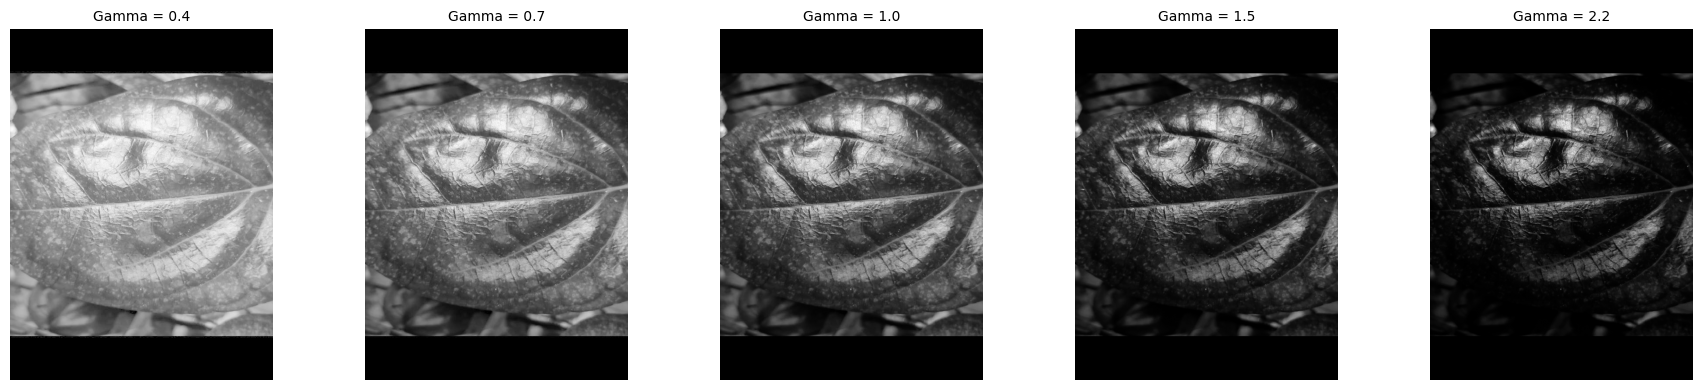

In [13]:
def gamma_correction(gray_image, gamma):
    """Apply gamma correction to an 8-bit grayscale image."""
    normalized = gray_image.astype(np.float32) / 255.0
    corrected = np.power(normalized, gamma) * 255.0
    return np.clip(corrected, 0, 255).astype(np.uint8)


gamma_values = [0.4, 0.7, 1.0, 1.5, 2.2]
gamma_images = [gamma_correction(image_gray, gamma) for gamma in gamma_values]

for gamma, gamma_img in zip(gamma_values, gamma_images):
    save_gray_image(OUTPUT_DIR / f"task04_gamma_{gamma}.png", gamma_img)

show_image_grid(
    gamma_images,
    titles=[f"Gamma = {gamma}" for gamma in gamma_values],
    cmap="gray",
    cols=5,
    figsize=(18, 4)
)

### Gamma Correction on RGB Image

The same transformation can be applied channel-wise to a color image. Here the transformation is applied to the RGB image after normalizing pixel values to `[0, 1]`.

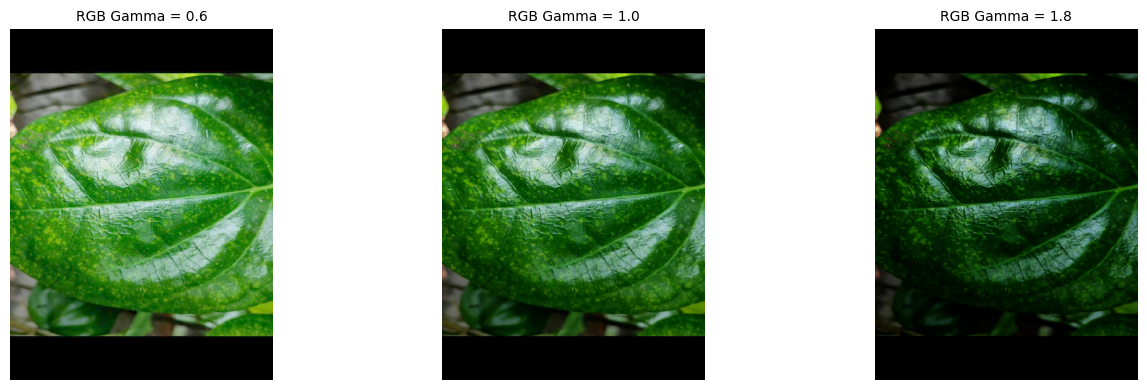

In [14]:
def gamma_correction_rgb(rgb_image, gamma):
    """Apply gamma correction channel-wise to an RGB image."""
    normalized = rgb_image.astype(np.float32) / 255.0
    corrected = np.power(normalized, gamma) * 255.0
    return np.clip(corrected, 0, 255).astype(np.uint8)


rgb_gamma_values = [0.6, 1.0, 1.8]
rgb_gamma_images = [gamma_correction_rgb(image_rgb, gamma) for gamma in rgb_gamma_values]

for gamma, rgb_gamma in zip(rgb_gamma_values, rgb_gamma_images):
    # Convert RGB back to BGR before saving with OpenCV.
    bgr_to_save = cv2.cvtColor(rgb_gamma, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(OUTPUT_DIR / f"task04_rgb_gamma_{gamma}.png"), bgr_to_save)

show_image_grid(
    rgb_gamma_images,
    titles=[f"RGB Gamma = {gamma}" for gamma in rgb_gamma_values],
    cmap=None,
    cols=3,
    figsize=(14, 4)
)

## Task 5: Visualize Transformation Curves

Transformation curves show how each input intensity value `r` is mapped to an output value `s`. These curves help students interpret why an image becomes brighter, darker, inverted, or contrast-enhanced after transformation.

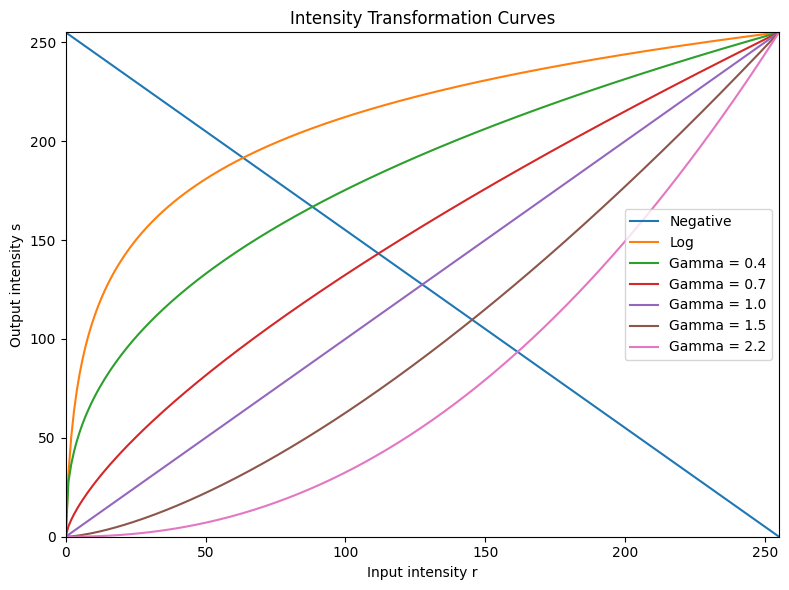

In [15]:
r = np.arange(0, 256, dtype=np.float32)

# Negative transformation
negative_curve = 255 - r

# Log transformation curve
log_curve = 255.0 / np.log1p(255.0) * np.log1p(r)

# Gamma transformation curves
gamma_curve_values = [0.4, 0.7, 1.0, 1.5, 2.2]
gamma_curves = {
    gamma: np.power(r / 255.0, gamma) * 255.0
    for gamma in gamma_curve_values
}

plt.figure(figsize=(8, 6))

plt.plot(r, negative_curve, label="Negative")
plt.plot(r, log_curve, label="Log")

for gamma, curve in gamma_curves.items():
    plt.plot(r, curve, label=f"Gamma = {gamma}")

plt.title("Intensity Transformation Curves")
plt.xlabel("Input intensity r")
plt.ylabel("Output intensity s")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.legend()
plt.tight_layout()
plt.show()

### Contrast Stretching Curve

For contrast stretching, the curve depends on the minimum and maximum intensity values of the input image. In this example, the low-contrast image range is mapped to the full `[0, 255]` range.

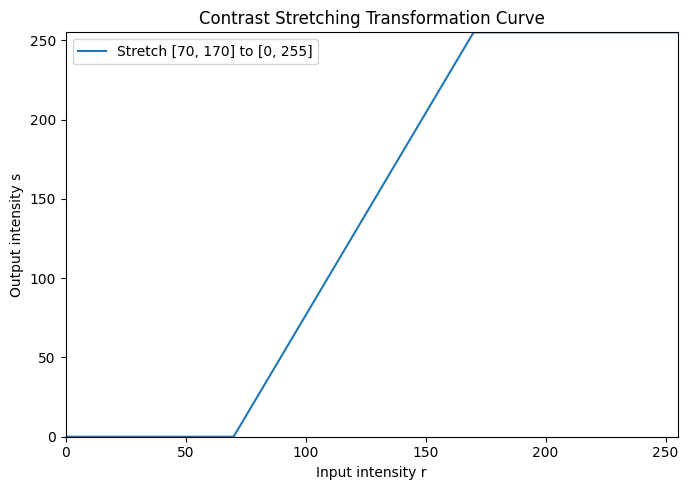

In [16]:
low_min = int(low_contrast_gray.min())
low_max = int(low_contrast_gray.max())

contrast_curve = np.zeros_like(r)

for i, value in enumerate(r):
    if value <= low_min:
        contrast_curve[i] = 0
    elif value >= low_max:
        contrast_curve[i] = 255
    else:
        contrast_curve[i] = (value - low_min) / (low_max - low_min) * 255

plt.figure(figsize=(7, 5))
plt.plot(r, contrast_curve, label=f"Stretch [{low_min}, {low_max}] to [0, 255]")
plt.title("Contrast Stretching Transformation Curve")
plt.xlabel("Input intensity r")
plt.ylabel("Output intensity s")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.legend()
plt.tight_layout()
plt.show()

## Saved Outputs

All generated images are saved in the following Kaggle working directory:

```text
/kaggle/working/cse438_lab03_outputs
```

These files can be downloaded from the Kaggle output panel after running the notebook.

In [17]:
print("Saved output files:")

for file_path in sorted(OUTPUT_DIR.glob("*")):
    print("-", file_path.name)

Saved output files:
- task01_negative_gray.png
- task02_contrast_stretched_gray.png
- task02_low_contrast_gray.png
- task03_log_magnitude_spectrum.png
- task03_log_transformed_gray.png
- task03_raw_magnitude_spectrum.png
- task04_gamma_0.4.png
- task04_gamma_0.7.png
- task04_gamma_1.0.png
- task04_gamma_1.5.png
- task04_gamma_2.2.png
- task04_rgb_gamma_0.6.png
- task04_rgb_gamma_1.0.png
- task04_rgb_gamma_1.8.png


In [18]:
# Summary:
# In this lab, we applied point operations and gray-level transformations to Betel Leaf images.
# The notebook demonstrated image negation, contrast stretching, log transformation for Fourier
# spectrum display, gamma correction, and transformation-curve visualization. These operations
# provide the foundation for later enhancement, filtering, segmentation, and restoration labs.